In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# reading the csv as a dataframe 
df=pd.read_csv("MATH3888/centrality_measures.csv")

In [27]:
# defining a function that will plot any two centrality measures against each other
def centrality_plot(cen1, cen2):

    # checking that both the inputs are centrality measures
    col_names = df.columns
    match1 = False
    match2 = False
    for i in range(1, 8):
        if (cen1 == col_names[i]):
            match1 = True
        if (cen2 == col_names[i]):
            match2 = True
    if (match1 == False) or (match2 == False):
        raise ValueError
            

    # plotting the centrality measures against each other
    plt.scatter(df[cen1], df[cen2], alpha=0.5)
    plt.xlabel(cen1)
    plt.ylabel(cen2)
    plt.title(cen1+" vs "+cen2+" centrality")
    plt.show() 
    

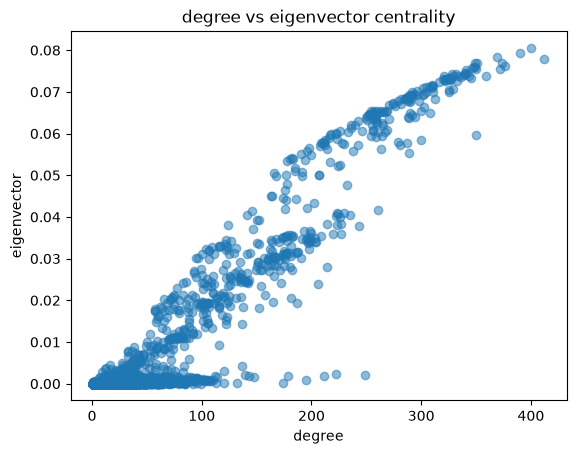

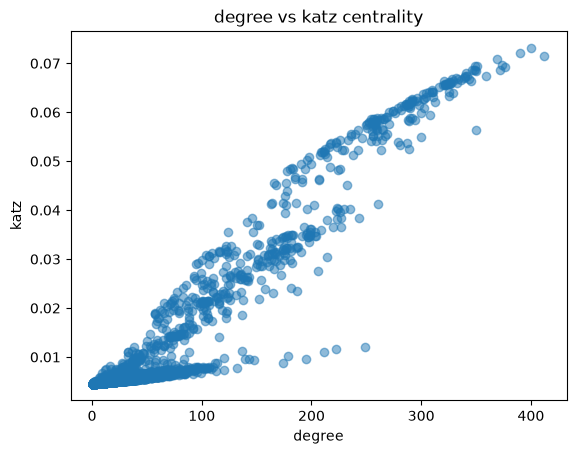

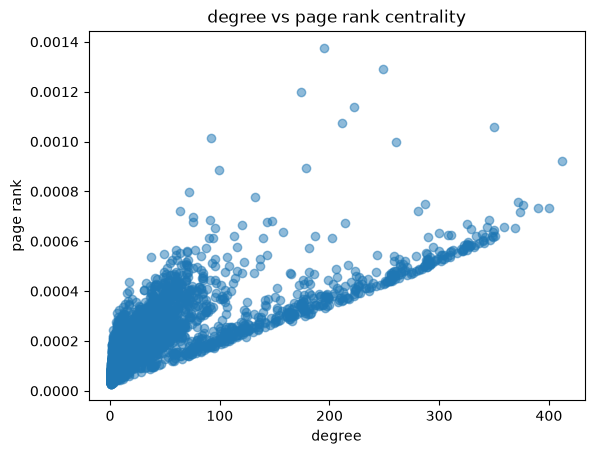

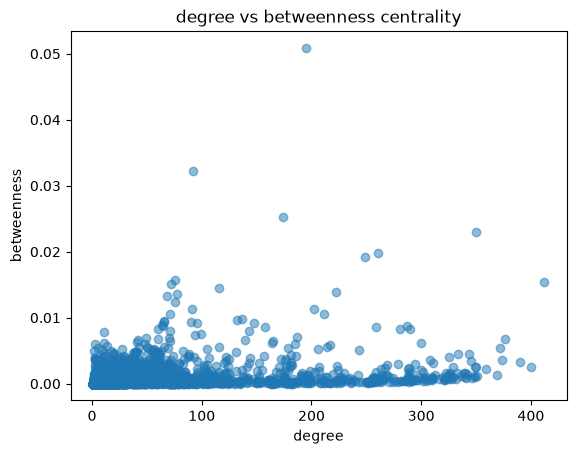

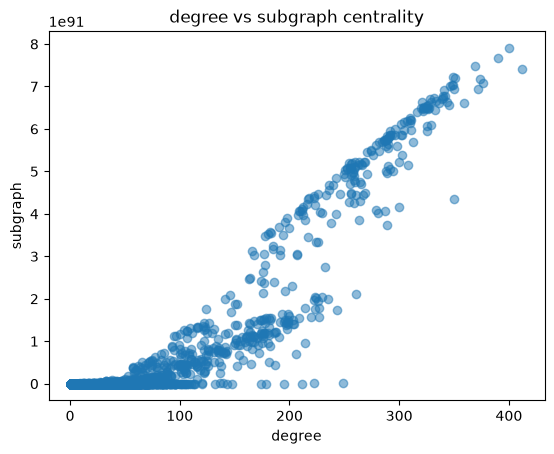

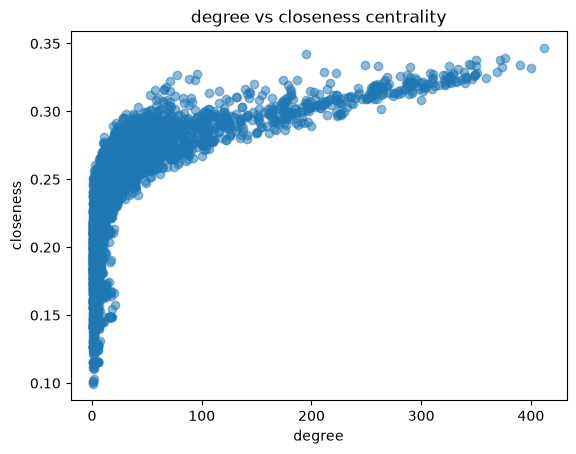

In [21]:
# plotting each centrality measure against degree:
centrality_plot("degree", "eigenvector")
centrality_plot("degree", "katz")
centrality_plot("degree", "page rank")
centrality_plot("degree", "betweenness")
centrality_plot("degree", "subgraph")
centrality_plot("degree", "closeness")

<function matplotlib.pyplot.show(close=None, block=None)>

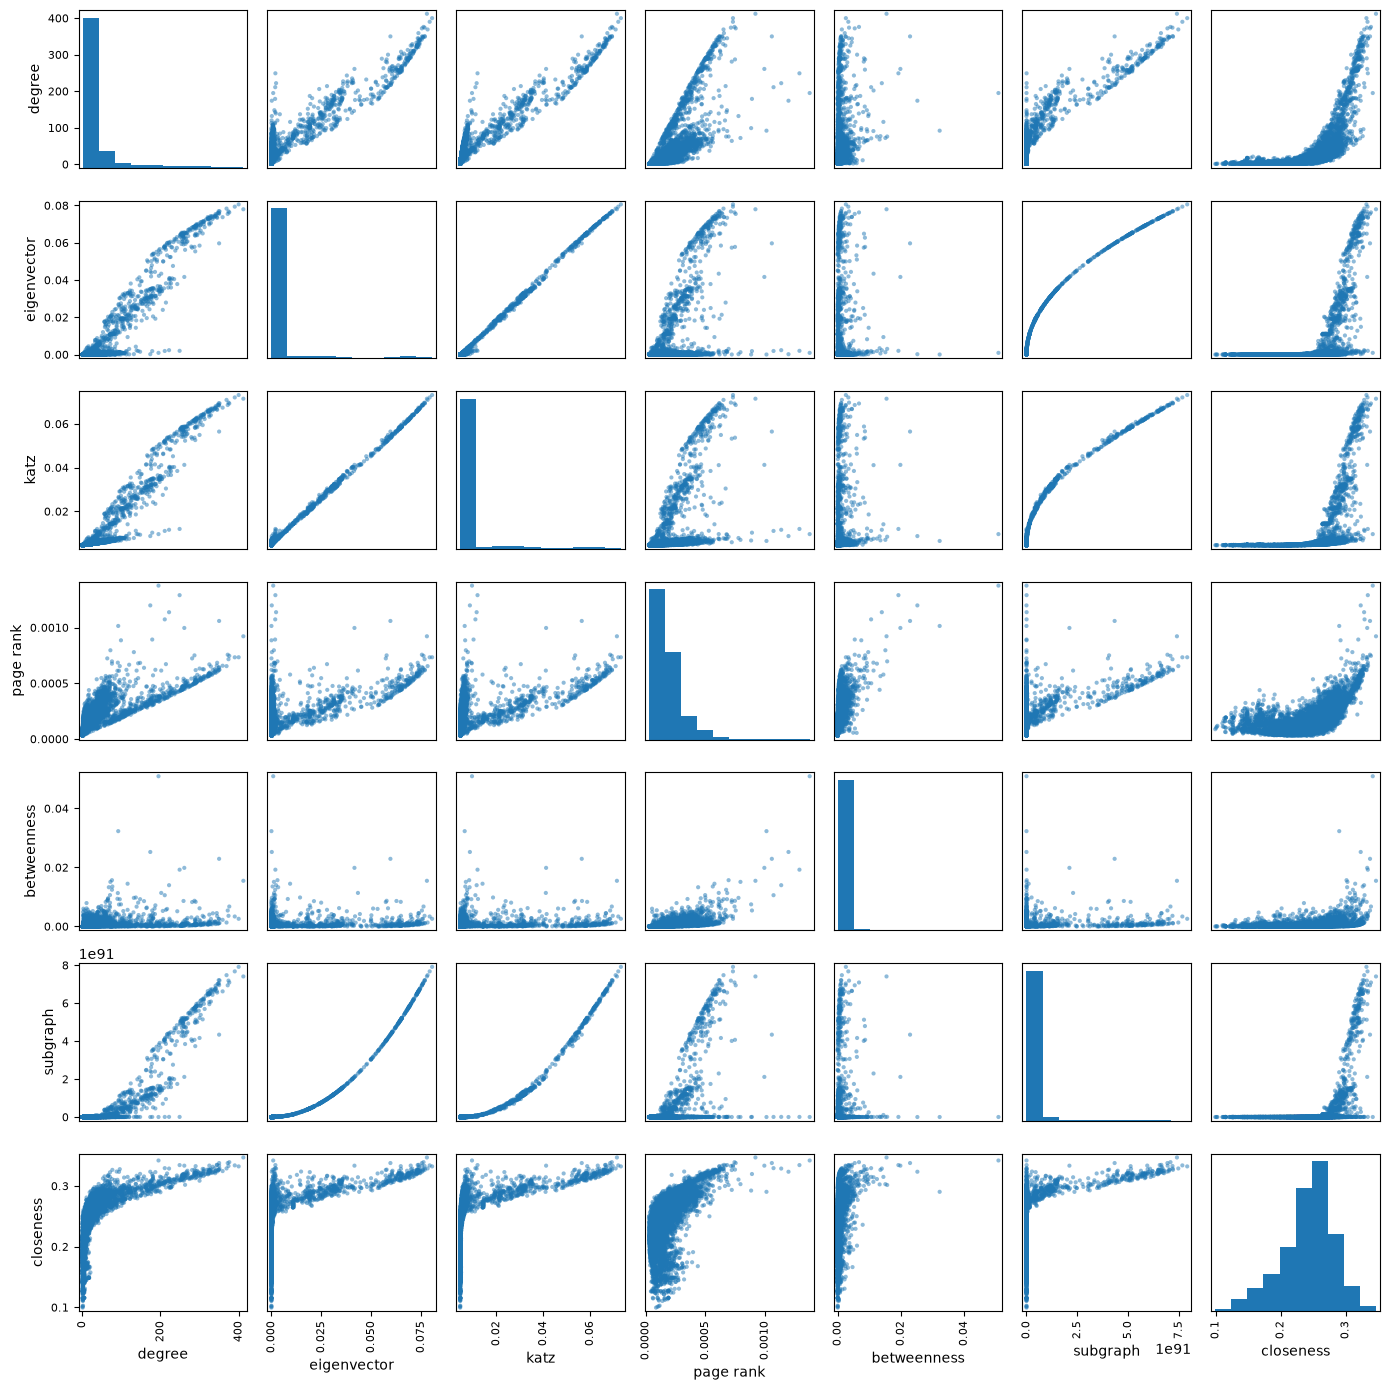

In [28]:
# making a matrix of all the centrality measures against each other
centrality_cols=["degree", "eigenvector", "katz", "page rank", "betweenness", "subgraph", "closeness"]

pd.plotting.scatter_matrix(
    df[centrality_cols],
    figsize=(14, 14), 
    diagonal="hist",
    alpha=0.5
)

plt.tight_layout()
plt.show

In [9]:
# calculating the correlations between the centrality measures:
centrality_cols=["degree", "eigenvector", "katz", "page rank", "betweenness", "subgraph", "closeness"]
correlation_matrix = df[centrality_cols].corr()

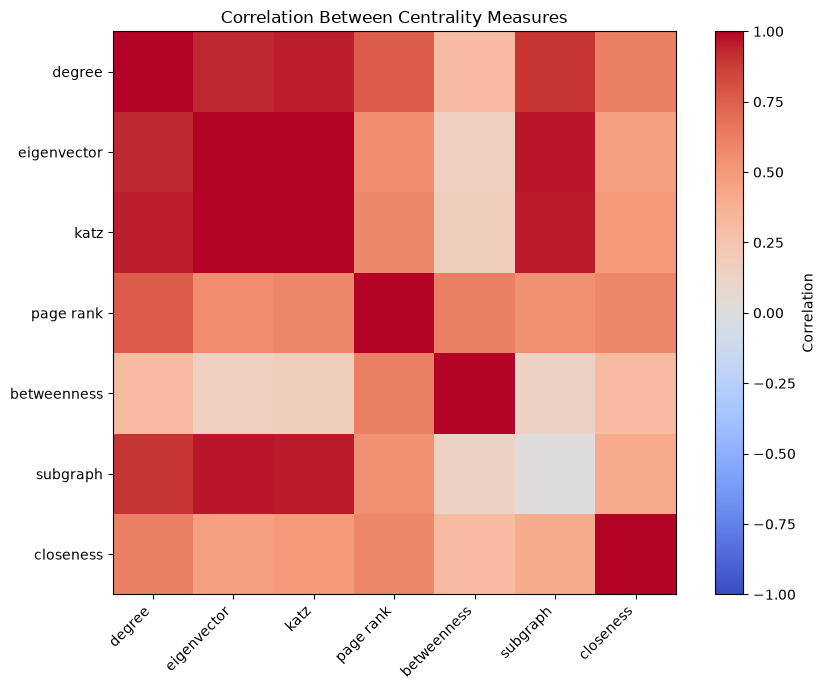

In [ ]:
# plotting the correlation. More red = more correlated, more blue = less correlated
plt.figure(figsize=(9,7))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(centrality_cols)), centrality_cols, rotation=45, ha="right")
plt.yticks(range(len(centrality_cols)), centrality_cols)
plt.title("Correlation Between Centrality Measures")
plt.tight_layout()
plt.show()

Here, the subgraph values are much larger than the other centrality measures. I think pandas runs into numerical precision issues when computing this matrix, which is why the (subgraph, subgraph) box isn't red like expected. Scaling the subgraph values down to make another matrix:

In [ ]:
centrality_scaled = df[centrality_cols].copy()
centrality_scaled["subgraph"] = centrality_scaled["subgraph"]/1e90
correlation_scaled = centrality_scaled.corr()


1.0


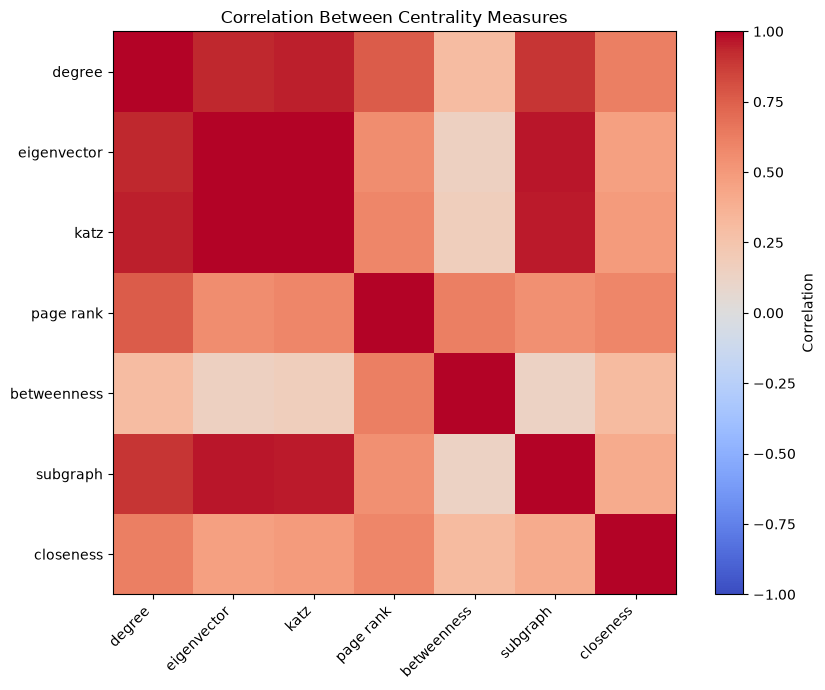

In [12]:
# printing the new heatmap of the correlation matrix:
plt.figure(figsize=(9,7))
plt.imshow(correlation_scaled, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(centrality_cols)), centrality_cols, rotation=45, ha="right")
plt.yticks(range(len(centrality_cols)), centrality_cols)
plt.title("Correlation Between Centrality Measures")
plt.tight_layout()
plt.show()